# 01 — One request, three ways

This is the spine of the workshop. Everything after it is a variation.

We will fetch **one** thing — sea surface temperature off Monterey Bay, one point per
day for September 2019 — and express the same fetch three ways:

| | what it shows you |
|---|---|
| **1. `curl`** | what is actually on the wire, including the parts every library hides from you |
| **2. `requests`** | the Python idiom, and the one thing it must do that `curl` does not |
| **3. `xarray`** | when a domain library has already solved the problem for you |

The order matters. Most people meet step 2 first, use it for a year, and never find out
that step 1 would have told them why their query was malformed.

## The site

Everything in this workshop is within about 20 km of one point in Monterey Bay.

| | |
|---|---|
| Ocean site | 36.70 N, 122.10 W — the centre of everything we will compute |
| Acoustic recorder | 36.798 N, 121.976 W — SanctSound **MB01**, 16 km away, 116 m deep |
| Wind | NDBC buoy **46092** "MBM1", 10 km away |

The recorder and the buoy are real instruments moored in the same bay as the
reanalysis grid cell we are about to read. That is what makes it possible to ask a
question about *why* the ocean and the underwater sound behave as they do, rather than
only describing them.

In [1]:
import sys
from pathlib import Path

# notebooks/ holds _fetch.py and _sources.py; src/ holds the project's own helpers.
for p in (Path.cwd(), Path.cwd() / ".." / "src"):
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p.resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import _fetch
import _sources as S

# A real requests.Session, with a disk cache. Everything you use below -- .get,
# .text, .content, .json, .status_code, .raise_for_status, params= -- is
# ordinary `requests`. The cache is invisible at the call site.
http = _fetch.session()

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

_fetch.OFFLINE and print("offline mode: serving prefetched responses")

offline mode: serving prefetched responses


## 1. What you should get

State the expectation before the request. This is the habit that separates "I got some
data" from "I got **the right** data", and the failure it catches is the expensive one:
a `200 OK` containing plausible nonsense.

| | |
|---|---|
| Response | 1,324 bytes, 30 data rows, 4 columns |
| Columns | `time`, `latitude`, `longitude`, `analysed_sst` |
| SST at this cell | 15.08 – 17.02 °C, mean **15.97** °C |
| Whole 0.22° box, for contrast | 690,813 bytes, 15,870 rows, mean 15.58 °C |

About 15–17 °C is what you expect for a central-California upwelling coast in
September: cold for a California summer, because upwelling is pulling cold water up
from depth. If you get 22 °C you have probably asked for the wrong hemisphere or the
wrong month, and no amount of plotting will tell you.

Note that the single cell is *warmer* than the box average (15.97 vs 15.58). That is not
noise — it is the upwelling structure, and we plot it at the end to show why.

In [2]:
# Build the query. `point=True` collapses the lat/lon box to a single cell.
URL = S.sst_csv(point=True)
print(URL)
print()
print("Broken up:")
for part, label in [
    (S.ERDDAP,          "the griddap endpoint for this dataset"),
    (".csv",            "the format -- swap for .nc, .json, .html, ... "),
    ("?analysed_sst",   "the variable we want"),
    ("[(t0):(t1)]",     "time range"),
    ("[(lat):(lat)]",   "latitude -- a degenerate range, i.e. one cell"),
    ("[(lon):(lon)]",   "longitude"),
]:
    print(f"  {label:52} {part}")

https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41.csv?analysed_sst[(2019-09-01T00:00:00Z):(2019-09-30T00:00:00Z)][(36.6):(36.6)][(-122.2):(-122.2)]

Broken up:
  the griddap endpoint for this dataset                https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41
  the format -- swap for .nc, .json, .html, ...        .csv
  the variable we want                                 ?analysed_sst
  time range                                           [(t0):(t1)]
  latitude -- a degenerate range, i.e. one cell        [(lat):(lat)]
  longitude                                            [(lon):(lon)]


## 2. On the wire — `curl`

`curl` sends the request and prints the response with nothing in between. It is the
closest thing to reading the HTTP exchange off the network, and it is how you find out
what a library is doing on your behalf.

### ⚠️ Trap — `curl` reads `[` and `]` as glob patterns

Before we can run it: the URL is full of square brackets, because that is what ERDDAP's
index syntax uses. `curl` has treated `[...]` as a **glob range** since 7.21 — the same
feature that lets you do `curl 'https://x/[1-10].txt'` — and with no matching host it
fails with **exit code 3, `URL malformat`**, and *no error message at all* under `-s`.

So the first thing you see is an empty response and no explanation. The fix is one flag:

| | |
|---|---|
| `curl -s URL` | exit 3, 0 bytes, silent |
| `curl -s -g URL` | exit 0, 1,324 bytes |

`-g` / `--globoff` disables globbing. You will need it for every griddap URL, and you
will need to *know* you need it, because nothing tells you.

In [3]:
import shutil
import subprocess

# Also defined earlier, so this cell runs on its own. People jump to cells.
URL = S.sst_csv(point=True)

if shutil.which("curl"):
    for label, flags in [("without -g", ["-s"]), ("with -g", ["-s", "-g"])]:
        r = subprocess.run(
            ["curl", *flags, "--max-time", "30", URL], capture_output=True, text=True
        )
        print(f"  {label:12} exit {r.returncode}   {len(r.stdout):>6,} bytes")
    print()

    out = subprocess.run(
        ["curl", "-s", "-g", "--max-time", "30", URL], capture_output=True, text=True
    ).stdout
    lines = out.splitlines()
    print(f"  {len(lines)} lines, {len(out.encode()):,} bytes")
    print()
    for ln in lines[:4]:
        print("   |", ln[:76])
    print("   |  ...")
else:
    print("curl not found (it ships with macOS, Linux and Windows 10+).")
    print("Python equivalent:")
    print(http.get(URL).text[:400])

  without -g   exit 3        0 bytes


  with -g      exit 0    1,324 bytes



  32 lines, 1,324 bytes

   | time,latitude,longitude,analysed_sst
   | UTC,degrees_north,degrees_east,degree_C
   | 2019-09-01T09:00:00Z,36.6,-122.2,16.383
   | 2019-09-02T09:00:00Z,36.6,-122.2,15.747
   |  ...


### ⚠️ Trap — ERDDAP CSV has **two** header rows

Look at the first two lines above. The first is column *names*, the second is column
*units*. That second row is not a comment and not a footnote — it is a data row as far
as `pandas` is concerned, so a naive `read_csv` gives you a first row of strings and an
off-by-one on every subsequent row.

This is the single most common way to get silently corrupted data out of ERDDAP: no
error, no warning, just a frame where one temperature is the string `degree_C`.

In [4]:
url = S.sst_csv(point=True)
raw = http.get(url)
print(raw.text)

  !! NETWORK UNAVAILABLE -- serving the cached response
  !!   reason : offline mode (OCEAN_DATA_WORKSHOP_OFFLINE=1)
  !!   fetched: 2026-09-29 08:55
  !!   age    : 2 h
  !!   the numbers below are real data, but not necessarily current.
time,latitude,longitude,analysed_sst
UTC,degrees_north,degrees_east,degree_C
2019-09-01T09:00:00Z,36.6,-122.2,16.383
2019-09-02T09:00:00Z,36.6,-122.2,15.747
2019-09-03T09:00:00Z,36.6,-122.2,15.595
2019-09-04T09:00:00Z,36.6,-122.2,15.597
2019-09-05T09:00:00Z,36.6,-122.2,15.637
2019-09-06T09:00:00Z,36.6,-122.2,15.552
2019-09-07T09:00:00Z,36.6,-122.2,15.166
2019-09-08T09:00:00Z,36.6,-122.2,15.371
2019-09-09T09:00:00Z,36.6,-122.2,15.794
2019-09-10T09:00:00Z,36.6,-122.2,15.857
2019-09-11T09:00:00Z,36.6,-122.2,15.764
2019-09-12T09:00:00Z,36.6,-122.2,15.705
2019-09-13T09:00:00Z,36.6,-122.2,15.712
2019-09-14T09:00:00Z,36.6,-122.2,15.394
2019-09-15T09:00:00Z,36.6,-122.2,15.243
2019-09-16T09:00:00Z,36.6,-122.2,15.075
2019-09-17T09:00:00Z,36.6,-122.2,15.19099999

## 3. In Python — `requests`

The Python equivalent. Note what is *absent* compared to the notebook's helper: no
timeout, and no IPv4 forcing. Both matter, and both are traps — we come back to them.

> **Fast lane.** If you are comfortable with raw HTTP, start at the cell
> marked *three ways, step 2*. You will lose nothing by skipping the curl cell.

In [5]:
import requests

r = requests.get(URL)          # no timeout: this can hang forever, which is its own bug
print("status :", r.status_code)
print("bytes  :", len(r.content))
print("first  :", r.text.splitlines()[0])

status : 200
bytes  : 1324
first  : time,latitude,longitude,analysed_sst


### ⚠️ Trap — you cannot build a griddap query with `params=`

This is the trap that costs the most time, because the index expression
`[(t0):(t1)][(lat)][(lon)]` is part of the **parameter name**, not its value. The wire
format has no `=` after it:

```
...jplMURSST41.csv?analysed_sst[(2019-09-01...):(2019-09-30...)][(36.6):(36.6)][...]
                       ^^^^^^^^^^^^^^^ the whole thing is the KEY
```

And `requests` cannot express that through `params=` in **either** direction. Both
attempts were run against the live server:

| what you write | what goes on the wire | what ERDDAP replies |
|---|---|---|
| `params={expr: None}` | the parameter is **dropped entirely** | `500` — `destinationVariableName=... wasn't found` |
| `params={expr: ""}` | `...%5D=` — a trailing `=` | `500` — the same error |

The two different mistakes produce the *same* opaque 500, which is why the cause is
hard to see from the symptom. The fix is to build the query string by hand and pass it
as the URL.

In [6]:
# Show exactly what `requests` would put on the wire, for each of the two mistakes.
# No network needed -- this is just string assembly, so it works offline too.
import requests

expr = "[(2019-09-01T00:00:00Z):(2019-09-30T00:00:00Z)][(36.6):(36.6)][(-122.2):(-122.2)]"

def query_of(params):
    """The query string requests would send -- or the fact that there is none."""
    u = requests.Request("GET", S.ERDDAP + ".csv", params=params).prepare().url
    return u.split("?", 1)[1] if "?" in u else None

print("mistake 1 -- value None:")
q = query_of({"analysed_sst" + expr: None})
print("    query string:", q)
print("    ^ None. requests dropped the parameter, so the URL has no '?' at all,")
print("      and ERDDAP is asked for the whole dataset with no variable selected.")

print()
print("mistake 2 -- value empty string:")
q = query_of({"analysed_sst" + expr: ""})
print("   ", q[:86], "...")
print("    ^ note the trailing %5D= -- ERDDAP rejects the whole query.")

print()
print("what actually works -- hand-built, passed as the URL:")
print("   ", URL.split("?", 1)[1][:86], "...")
print("    ^ no '=' after the index expression, which is what ERDDAP expects.")

mistake 1 -- value None:
    query string: None
    ^ None. requests dropped the parameter, so the URL has no '?' at all,
      and ERDDAP is asked for the whole dataset with no variable selected.

mistake 2 -- value empty string:
    analysed_sst%5B%282019-09-01T00%3A00%3A00Z%29%3A%282019-09-30T00%3A00%3A00Z%29%5D%5B%2 ...
    ^ note the trailing %5D= -- ERDDAP rejects the whole query.

what actually works -- hand-built, passed as the URL:
    analysed_sst[(2019-09-01T00:00:00Z):(2019-09-30T00:00:00Z)][(36.6):(36.6)][(-122.2):(- ...
    ^ no '=' after the index expression, which is what ERDDAP expects.


### ⚠️ Trap — how you *reduce* an ERDDAP response (three ways that do not work)

The natural instinct, when you want one point per day instead of a full grid, is to ask
the server for less. Three obvious-looking approaches were tested against the live
server for September 2019 at this site:

| approach | result |
|---|---|
| full box, 0.22° square | **690,813 B**, 15,870 rows (23 × 23 cells per day) |
| `&.time=first&.lat=first&.lon=first` | **690,813 B** — *byte-identical. A no-op.* |
| `&time=...&latitude=...` (constraint variables) | `400` — *"must be followed by a .griddap server variable"* |
| strides in the index, `[(0):(1):(29)]` | `400` — *"axis#0=time Constraint=..."* |
| **a degenerate box, `[(36.6):(36.6)]`** | **1,324 B**, 30 rows — a 520× reduction |

The `.time=first` one is the dangerous one: it is in the examples people copy, it looks
like it is doing something, and it does nothing at all. ERDDAP's griddap DSL has no
strides and no constraint variables.

**Shrink the box instead.** That is the whole trick, and `_sources.sst_url(point=True)`
is the one line that does it.

In [7]:
box = http.get(S.sst_csv())
point = http.get(S.sst_csv(point=True))
print(f"  full box : {len(box.content):>9,} B   {len(box.text.splitlines()) - 2:>6,} rows")
print(f"  one point: {len(point.content):>9,} B   {len(point.text.splitlines()) - 2:>6,} rows")
print(f"  ratio    : {len(box.content) / len(point.content):,.0f}x smaller")

  !! NETWORK UNAVAILABLE -- serving the cached response
  !!   reason : offline mode (OCEAN_DATA_WORKSHOP_OFFLINE=1)
  !!   fetched: 2026-09-29 08:55
  !!   age    : 2 h
  !!   the numbers below are real data, but not necessarily current.
  !! NETWORK UNAVAILABLE -- serving the cached response
  !!   reason : offline mode (OCEAN_DATA_WORKSHOP_OFFLINE=1)
  !!   fetched: 2026-09-29 08:55
  !!   age    : 2 h
  !!   the numbers below are real data, but not necessarily current.
  full box :   690,813 B   15,870 rows
  one point:     1,324 B       30 rows
  ratio    : 522x smaller


### ⚠️ Trap — two header rows, again, now in pandas

Fix: skip the units row explicitly. `skiprows=[1]` keeps row 0 (the names) and drops
row 1 (the units).

In [8]:
import io

# Re-fetched rather than reusing `raw` from eight cells earlier: a variable defined
# that far up breaks the moment someone runs this cell alone.
raw = http.get(S.sst_csv(point=True))

df = pd.read_csv(io.StringIO(raw.text), skiprows=[1])
df["time"] = pd.to_datetime(df["time"].str.replace("Z", "", regex=False))

print(df.head(3).to_string(index=False))
print()
print("dtypes:", dict(df.dtypes.astype(str)))

  !! NETWORK UNAVAILABLE -- serving the cached response
  !!   reason : offline mode (OCEAN_DATA_WORKSHOP_OFFLINE=1)
  !!   fetched: 2026-09-29 08:55
  !!   age    : 2 h
  !!   the numbers below are real data, but not necessarily current.
               time  latitude  longitude  analysed_sst
2019-09-01 09:00:00      36.6     -122.2        16.383
2019-09-02 09:00:00      36.6     -122.2        15.747
2019-09-03 09:00:00      36.6     -122.2        15.595

dtypes: {'time': 'datetime64[us]', 'latitude': 'float64', 'longitude': 'float64', 'analysed_sst': 'float64'}


### ⚠️ Trap — IPv6, and why `requests` can be 100× slower than `curl`

Some machines — including the one this workshop was written on — resolve AAAA records
but have **no IPv6 route**.

`curl` races the two address families (Happy Eyeballs, RFC 8305), so it connects over
IPv4 immediately and looks perfectly healthy. `requests`, built on urllib3, waits out
the **full connect timeout** on the dead IPv6 address before falling back.

Measured on the same machine, same URL:

```
curl      0.20 s
requests  20.0 s   -- and 20.0 s is exactly the timeout value
```

The tell is that *every* call takes precisely the timeout. It reads like "this API is
slow" rather than "this API is fine and something on my machine is wrong".

There is no clean fix in `requests` itself, so the workshop's helper forces IPv4 once at
import. You do not need to do anything about this — but if a colleague ever tells you
their ERDDAP calls are mysteriously slow, this is why.

In [9]:
import socket
from ocean_data_workshop.http import force_ipv4

# What the machine resolves...
addrs = socket.getaddrinfo(S.ERDDAP.split("/")[2], 443, type=socket.SOCK_STREAM)
families = {socket.AddressFamily(i[0]).name for i in addrs}
print("  address families this host resolves:", ", ".join(sorted(families)))

# ...versus what we actually use.
already = force_ipv4()   # idempotent; False means it was already applied
print("  IPv4-only already active:", not already)
print("  -> every fetch in this workshop is unaffected by the above")

  address families this host resolves: AF_INET
  IPv4-only already active: True
  -> every fetch in this workshop is unaffected by the above


## 4. In a library — `xarray`

Now the escape hatch. The same data, asked for as netCDF instead of CSV, and handed
straight to `xarray`: labelled dimensions, coordinates, and no manual column assembly.

This is what you should reach for **after** you know what the wire format looks like.
A library hides structure you need to know about in order to debug it.

In [10]:
import io

import xarray as xr

nc = http.get(S.sst_nc())
path = Path.cwd() / "_sst_sep2019.nc"
path.write_bytes(nc.content)

ds = xr.open_dataset(path)
print(ds)
print()
print("the variable we asked for:", list(ds.data_vars))
print("its units attribute      :", ds[S.SST_VAR].attrs.get("units"))

  !! NETWORK UNAVAILABLE -- serving the cached response
  !!   reason : offline mode (OCEAN_DATA_WORKSHOP_OFFLINE=1)
  !!   fetched: 2026-09-29 08:55
  !!   age    : 2 h
  !!   the numbers below are real data, but not necessarily current.
<xarray.Dataset> Size: 127kB
Dimensions:       (time: 30, latitude: 23, longitude: 23)
Coordinates:
  * time          (time) datetime64[ns] 240B 2019-09-01T09:00:00 ... 2019-09-...
  * latitude      (latitude) float32 92B 36.6 36.61 36.62 ... 36.8 36.81 36.82
  * longitude     (longitude) float32 92B -122.2 -122.2 -122.2 ... -122.0 -122.0
Data variables:
    analysed_sst  (time, latitude, longitude) float64 127kB ...
Attributes: (12/50)
    acknowledgement:            Please acknowledge the use of these data with...
    cdm_data_type:              Grid
    comment:                    MUR = "Multi-scale Ultra-high Resolution"
    Conventions:                CF-1.6, COARDS, ACDD-1.3
    creator_email:              ghrsst@podaac.jpl.nasa.gov
    creator_

## 4b. Getting a response *into* a DataFrame

Everything so far has produced a `requests.Response`. A response is not a DataFrame, and
this step is where most of the real mistakes happen -- not in the request.

Four attributes carry the payload, and which one you need is decided by the format:

| attribute | what it is | use it for |
|---|---|---|
| `r.text` | body decoded to `str` | JSON, CSV, HTML -- anything human-readable |
| `r.content` | body as `bytes`, untouched | binary: netCDF, gzip, images |
| `r.json()` | body parsed as JSON | any JSON API |
| `r.headers` / `r.status_code` | metadata | checks before you trust the body |

`pandas` reads a **file-like object**, not a string and not a response. So you need one
thin adapter, and which one depends on whether you have text or bytes.

In [11]:
# 1. JSON -> DataFrame. The easy case: r.json() gives you ordinary Python objects.
gcs = http.get(S.GCS_API, params=S.gcs_list_params(
    f"sanctsound/products/sound_level_metrics/{S.NCEI_SITE}/", "/", 200))
body = gcs.json()
print("  top-level keys:", list(body))
print()
print("  Note which keys are actually present. We asked for delimiter='/', so the")
print("  server rolled the listing up into 'prefixes' and returned no 'items' at all:")
print("    prefixes:", len(body.get("prefixes", [])), " items:", len(body.get("items", [])))
print()
print("  An object listing is not a table, so you build one. Either list:")
rows = pd.DataFrame([{"prefix": p} for p in body.get("prefixes", [])])
print("   from prefixes ->", rows.shape)
print()
print("  ...or drop the delimiter and get flat objects with full metadata:")
flat = http.get(S.GCS_API, params=S.gcs_list_params(
    f"sanctsound/products/sound_level_metrics/{S.NCEI_SITE}/", "", 200)).json()
items = pd.DataFrame(flat["items"])
print("   from items    ->", items.shape)
print("   columns       :", list(items.columns))
print("   first name    :", items["name"].iloc[0])
print()
print("  pd.DataFrame(...) works on a dict of equal-length lists; pd.json_normalize")
print("  flattens one level for nested JSON. Which one you want depends on the")
print("  response you actually got -- so look at the keys before building.")

  !! NETWORK UNAVAILABLE -- serving the cached response
  !!   reason : offline mode (OCEAN_DATA_WORKSHOP_OFFLINE=1)
  !!   fetched: 2026-09-29 08:55
  !!   age    : 2 h
  !!   the numbers below are real data, but not necessarily current.
  top-level keys: ['kind', 'prefixes']

  Note which keys are actually present. We asked for delimiter='/', so the
  server rolled the listing up into 'prefixes' and returned no 'items' at all:
    prefixes: 36  items: 0

  An object listing is not a table, so you build one. Either list:
   from prefixes -> (36, 1)

  ...or drop the delimiter and get flat objects with full metadata:
  !! NETWORK UNAVAILABLE -- serving the cached response
  !!   reason : offline mode (OCEAN_DATA_WORKSHOP_OFFLINE=1)
  !!   fetched: 2026-09-29 08:55
  !!   age    : 2 h
  !!   the numbers below are real data, but not necessarily current.
   from items    -> (143, 18)
   columns       : ['kind', 'id', 'selfLink', 'mediaLink', 'name', 'bucket', 'generation', 'metageneration

In [12]:
# 2. Text -> DataFrame. pandas needs a file-like object, so wrap the string.
df = pd.read_csv(io.StringIO(http.get(URL).text), skiprows=[1])
print("  from r.text    ->", df.shape, list(df.columns))

# 3. Bytes -> DataFrame. BytesIO, not StringIO.
csv_bytes = http.get(S.sst_csv()).content
df2 = pd.read_csv(io.BytesIO(csv_bytes), skiprows=[1])
print("  from r.content ->", df2.shape, "   identical:", df.equals(df2))

  !! NETWORK UNAVAILABLE -- serving the cached response
  !!   reason : offline mode (OCEAN_DATA_WORKSHOP_OFFLINE=1)
  !!   fetched: 2026-09-29 08:55
  !!   age    : 2 h
  !!   the numbers below are real data, but not necessarily current.
  from r.text    -> (30, 4) ['time', 'latitude', 'longitude', 'analysed_sst']
  !! NETWORK UNAVAILABLE -- serving the cached response
  !!   reason : offline mode (OCEAN_DATA_WORKSHOP_OFFLINE=1)
  !!   fetched: 2026-09-29 08:55
  !!   age    : 2 h
  !!   the numbers below are real data, but not necessarily current.
  from r.content -> (15870, 4)    identical: False


In [13]:
# 4. Binary -> xarray. Some formats have no text form at all, so this is the only route.
nc_bytes = http.get(S.sst_nc()).content
path = Path.cwd() / "_from_bytes.nc"
path.write_bytes(nc_bytes)
ds = xr.open_dataset(path)
print("  netCDF via r.content ->", dict(ds.sizes))

ds2 = xr.open_dataset(io.BytesIO(nc_bytes))
print("  BytesIO works too    ->", dict(ds2.sizes))

  !! NETWORK UNAVAILABLE -- serving the cached response
  !!   reason : offline mode (OCEAN_DATA_WORKSHOP_OFFLINE=1)
  !!   fetched: 2026-09-29 08:55
  !!   age    : 2 h
  !!   the numbers below are real data, but not necessarily current.
  netCDF via r.content -> {'time': 30, 'latitude': 23, 'longitude': 23}


  BytesIO works too    -> {'time': 30, 'latitude': 23, 'longitude': 23}


In [14]:
# 5. Gzipped text is the trap in this section. NDBC serves .txt.gz.
gz = http.get(S.ndbc_url())
print("  r.content type :", type(gz.content).__name__, f"{len(gz.content):,}", "bytes")
print("  r.text   type  :", type(gz.text).__name__, f"{len(gz.text):,}", "chars")
print()
print("  r.text DECODES the gzip bytes as though they were plain text. It does not")
print("  decompress them. You get mojibake, and pd.read_csv on it gives nonsense")
print("  with no error at all. For .gz you must use r.content plus gzip:")
import gzip

text = gzip.decompress(gz.content).decode()
lines = text.splitlines()
print()
print("  after gzip.decompress:", len(lines), "lines")
print("  header:", lines[0][:62])

  !! NETWORK UNAVAILABLE -- serving the cached response
  !!   reason : offline mode (OCEAN_DATA_WORKSHOP_OFFLINE=1)
  !!   fetched: 2026-09-29 08:55
  !!   age    : 2 h
  !!   the numbers below are real data, but not necessarily current.
  r.content type : bytes 76,016 bytes
  r.text   type  : str 72,098 chars

  r.text DECODES the gzip bytes as though they were plain text. It does not
  decompress them. You get mojibake, and pd.read_csv on it gives nonsense
  with no error at all. For .gz you must use r.content plus gzip:

  after gzip.decompress: 7837 lines
  header: #YY  MM DD hh mm WDIR WSPD GST  WVHT   DPD   APD MWD   PRES  A


### The rule, in one line

**`r.text` for anything the server calls text. `r.content` for everything else, and
check `Content-Type` when you are unsure.**

```python
r = http.get(url)

r.raise_for_status()            # before you trust any of it
ctype = r.headers.get("Content-Type", "")
if "json" in ctype:
    df = pd.json_normalize(r.json())
elif "csv" in ctype:
    df = pd.read_csv(io.StringIO(r.text))
else:
    Path("payload.bin").write_bytes(r.content)   # netCDF, gzip, ...
```

Always `r.raise_for_status()` first. A 500 whose body is an error message is not JSON,
and calling `r.json()` on it raises a `JSONDecodeError` that tells you nothing -- you
have to check the status to read the message the server actually sent.

### And there is no magic in the session

`_fetch.session()` returns an ordinary `requests.Session`. It overrides exactly one
method, `send`, and that single override *is* the cache. The same code works without it:

```python
import requests
r = requests.get(url, timeout=(10, 120))     # that is the whole thing
```

The session adds two things and no more: it forces IPv4 (trap 6 above), and it falls
back to a cached response when the network fails. Everything else in this notebook --
`.get`, `params=`, `.text`, `.content`, `.json()`, `.status_code`, `.raise_for_status()`,
`.headers` -- is plain `requests`, and identical in your own project.

In [15]:
# Proof: it really is a requests.Session with one method overridden.
import requests

overridden = [m for m in ("get", "post", "send", "request") if m in vars(type(http))]
print("  type(http)          :", type(http).__name__)
print("  is a Session        :", isinstance(http, requests.Session))
print("  methods overridden  :", overridden)
print("  requests.get exists :", callable(requests.get))
print()
print("  One method, 'send'. Everything else is stock requests.")

  type(http)          : CachedSession
  is a Session        : True
  methods overridden  : ['send']
  requests.get exists : True

  One method, 'send'. Everything else is stock requests.


## 5. Traps so far

| # | trap | symptom | fix |
|---|---|---|---|
| 1 | ERDDAP CSV has two header rows | first row of strings, off-by-one everywhere | `pd.read_csv(..., skiprows=[1])` |
| 2 | index expression is part of the parameter *name* | `500 destinationVariableName=... wasn't found` | hand-build the URL; do not use `params=` |
| 3 | `.time=first` is a no-op | you get 500× more data than you asked for | shrink the box instead |
| 4 | constraint variables rejected | `400 must be followed by a .griddap server variable` | use the index form only |
| 5 | no `=` after the index expression | `500`, same as trap 2 | hand-build the URL |
| 6 | IPv6 with no route | every call takes exactly the timeout | force IPv4 (helper does it) |
| 7 | no timeout on `requests` | hangs forever on a dead host | always pass `timeout=` |

There are about 28 of these across the whole workshop. Notebook 09 is the full list.

## 6. What you got

September 2019 sea surface temperature at 36.6 N, 122.2 W — one point per day.

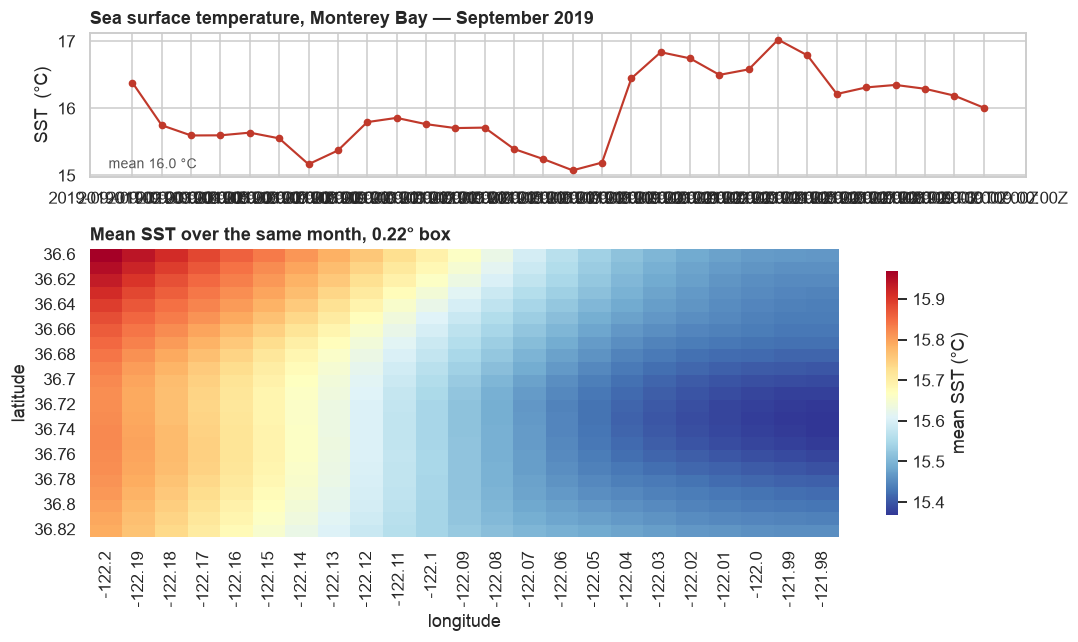

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), height_ratios=[1, 2])

ax = axes[0]
ax.plot(df["time"], df[S.SST_VAR], marker="o", ms=4, color="#c0392b", lw=1.4)
ax.set_ylabel("SST  (°C)")
ax.set_title("Sea surface temperature, Monterey Bay — September 2019", loc="left", fontweight="bold")
ax.annotate(
    f"mean {df[S.SST_VAR].mean():.1f} °C",
    xy=(0.02, 0.06), xycoords="axes fraction", fontsize=9, color="#555",
)

# The full box, as a mean field -- this is the upwelling structure the point sits in.
ax = axes[1]
grid = (
    pd.read_csv(io.StringIO(box.text), skiprows=[1])
      .query("analysed_sst > -1")
      .groupby(["latitude", "longitude"])[S.SST_VAR].mean()
      .unstack()
)
sns.heatmap(grid, cmap="RdYlBu_r", ax=ax, cbar_kws={"label": "mean SST (°C)", "shrink": 0.85})
ax.set_title("Mean SST over the same month, 0.22° box", loc="left", fontweight="bold")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")

plt.tight_layout()
plt.show()

The point sits in the *warm* part of the box. Monterey Bay is a classic **upwelling
system**: a cool filament of water drawn from depth runs along the coast just outside,
and the bay itself is a degree or two warmer. Seeing the point in context is the
difference between a number and an observation — and it is why "which cell did I
download?" is a real question worth asking before you trust any single value.

In [17]:
# Assert the response is what this notebook said it would be.
# Built here as well, so the notebook's final cell can be run on its own.
raw = http.get(S.sst_csv(point=True))
df = pd.read_csv(io.StringIO(raw.text), skiprows=[1])

_fetch.expect("response bytes", len(raw.content), 1324)
_fetch.expect("rows", len(df), 30)
_fetch.expect("columns", list(df.columns), ["time", "latitude", "longitude", "analysed_sst"])
_fetch.expect_range("mean SST", df[S.SST_VAR].mean(), 15.5, 16.5)
_fetch.expect_range("SST min", df[S.SST_VAR].min(), 14.5, 16.0)
_fetch.expect_range("SST max", df[S.SST_VAR].max(), 13.0, 19.0)
print()
print("  14-17 C in September is upwelling-consistent for central California.")
print("  Had any of these failed, the number would have been wrong, not the plot.")

  !! NETWORK UNAVAILABLE -- serving the cached response
  !!   reason : offline mode (OCEAN_DATA_WORKSHOP_OFFLINE=1)
  !!   fetched: 2026-09-29 08:55
  !!   age    : 2 h
  !!   the numbers below are real data, but not necessarily current.
  ok  response bytes: got 1324, expected 1324
  ok  rows: got 30, expected 30
  ok  columns: got ['time', 'latitude', 'longitude', 'analysed_sst'], expected ['time', 'latitude', 'longitude', 'analysed_sst']
  ok  mean SST: 15.968666666666667 in [15.5, 16.5]
  ok  SST min: 15.075 in [14.5, 16.0]
  ok  SST max: 17.023 in [13.0, 19.0]

  14-17 C in September is upwelling-consistent for central California.
  Had any of these failed, the number would have been wrong, not the plot.
